### Data Preprocessing

# **Mini Project 2 - CAPO TCS**
#### **Nik, Sal, and Samia (Team Pineapple)**

In [ ]:
# Install the required libraries for Data Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


Matplotlib is building the font cache; this may take a moment.


In [163]:
# Install the required librabries for Linear Regression
import sklearn.model_selection as model_selection
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Install the required libraries for Logistic Regression 

In [124]:
data = pd.read_csv('capo_data.csv')

data.head()

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___wbc,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral
0,16,43.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,0,1,0,0,1,1,1,1
1,17,60.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,18,45.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,0,0,0,0,0,0,0,0
3,19,35.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
4,20,61.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [125]:
#data.info()
#We have a bunch of columns that are missing the
#full 8230 rows in the dataset. The day test
#and case id values are all integers, otherwise, all
#other columns are floats. 
print(f'dataset is {data.shape[0]} by {data.shape[1]}')

dataset is 8230 by 100


In [126]:
#data.columns

In [127]:
#Check for null values in the data
#data.isna().sum().sort_values(ascending=False)
#data.isnull().sum()

In [128]:
#Need to .dropna(how = '', axis = 0 for rows and 1 columns)
#and fillna some columns with mode and mean. 

In [129]:
#Dropping columns to leave only 'exam', 'dem', 'cx', and 'test' data per rubric.
data2 = data.drop(['lab_hematocrit', 'lab_hemoglobin', 'lab_bands', 'lab_platelets', 'lab_inr', 'lab_na', 'lab_k', 'lab_bun',
       'lab_creatinine', 'lab_bicarb', 'lab_glucose', 'lab_albumin', 'lab_ast',
       'lab_alt', 'lab_bilirubin', 'lab_trop1', 'lab_trop2', 'lab_trop3',
       'lab_ckmb1', 'lab_ckmb2', 'lab_ckmb3', 'lab_ldl', 'lab_hdl',
       'lab_cholesterol', 'lab_triglycerides', 'lab_lactate', 'lab_hga1c',
       'lab_ldh', 'lab_bnp', 'lab_crp', 'lab_pct', 'lab_vitamind', 'lab_abg',
       'lab_abgph', 'lab_abgpaco2', 'lab_abgpao2', 'lab_abgbicarb',
       'lab_abgfio2'], axis=1)
data2.columns

Index(['case_id', 'dem_age', 'dem_sex', 'dem_pregnant', 'dem_trimester',
       'exam_height', 'exam_weight', 'exam_hr', 'exam_rr', 'exam_sbp',
       'exam_dbp', 'exam_temp', 'exam_o2sat', 'exam_o2satvalue', 'exam_fio2',
       'exam_mental', 'lab_wbc', 'cx_rul', 'cx_rml', 'cx_rll', 'cx_lul',
       'cx_lll', 'cx_db', 'cx_du', 'cx_cav', 'cx_pe', 'day0test___cough',
       'day0test___afebrile', 'day0test___wbc', 'day0test___oral',
       'day1test___cough', 'day1test___afebrile', 'day1test___wbc',
       'day1test___oral', 'day2test___cough', 'day2test___afebrile',
       'day2test___wbc', 'day2test___oral', 'day3test___cough',
       'day3test___afebrile', 'day3test___wbc', 'day3test___oral',
       'day4test___cough', 'day4test___afebrile', 'day4test___wbc',
       'day4test___oral', 'day5test___cough', 'day5test___afebrile',
       'day5test___wbc', 'day5test___oral', 'day6test___cough',
       'day6test___afebrile', 'day6test___wbc', 'day6test___oral',
       'day7test___cough', '

In [130]:
#dropping all rows which sex and exam_mental is null
data2 = data2.dropna(subset=["dem_sex"])
data2 = data2.dropna(subset=["exam_mental"])

In [131]:
# Checking for amount of null values present
pd.set_option('display.max_rows', None)

data2.isnull().sum().sort_values(ascending=False)

dem_trimester              7721
cx_du                      7402
cx_db                      7395
dem_pregnant               6907
exam_fio2                  5951
exam_rr                    4782
exam_height                4765
exam_weight                4681
exam_o2satvalue            4436
exam_dbp                   4265
exam_sbp                   4262
exam_o2sat                 4162
exam_hr                    2779
exam_temp                  2770
lab_wbc                    2765
cx_rul                       35
cx_lul                       31
cx_rml                       29
cx_lll                       28
cx_rll                       28
cx_cav                       16
cx_pe                        11
dem_age                       1
dem_sex                       0
case_id                       0
exam_mental                   0
day0test___cough              0
day0test___afebrile           0
day0test___wbc                0
day0test___oral               0
day1test___cough              0
day1test

In [132]:
#Dropping these three columns due to insufficient quanity. 
data2 = data2.drop(['cx_du', 'cx_db', 'exam_fio2'], axis=1)

In [133]:
#imputing missing values so that all there are no missing values
imputation_dict = {
    'dem_trimester': 0,
    'dem_pregnant': 0,
    'dem_age': data2['dem_age'].mean(),
    'exam_temp': data2['exam_temp'].mean(),
    'exam_hr': data2['exam_hr'].mean(),
    'exam_rr': data2['exam_rr'].mean(),
    'exam_sbp': data2['exam_sbp'].mean(),
    'exam_dbp': data2['exam_dbp'].mean(),
    'exam_o2satvalue': data2['exam_o2satvalue'].mean(),
    'exam_height': data2['exam_height'].mean(),
    'exam_weight': data2['exam_weight'].mean(),
    'lab_wbc': data2['lab_wbc'].mean(),

    'exam_o2sat': data2['exam_o2sat'].mode()[0],
    'cx_rul': data2['cx_rul'].mode()[0],
    'cx_lul': data2['cx_lul'].mode()[0],
    'cx_rml': data2['cx_rml'].mode()[0],
    'cx_rll': data2['cx_rll'].mode()[0],
    'cx_lll': data2['cx_lll'].mode()[0],
    'cx_cav': data2['cx_cav'].mode()[0],
    'cx_pe': data2['cx_pe'].mode()[0],
}
#Imputed the mean for continuous measures, mode for others. 

In [134]:
# Checking if missing values were imputed
data3 = data2.fillna(value=imputation_dict)
data3.isnull().sum()

case_id                    0
dem_age                    0
dem_sex                    0
dem_pregnant               0
dem_trimester              0
exam_height                0
exam_weight                0
exam_hr                    0
exam_rr                    0
exam_sbp                   0
exam_dbp                   0
exam_temp                  0
exam_o2sat                 0
exam_o2satvalue            0
exam_mental                0
lab_wbc                    0
cx_rul                     0
cx_rml                     0
cx_rll                     0
cx_lul                     0
cx_lll                     0
cx_cav                     0
cx_pe                      0
day0test___cough           0
day0test___afebrile        0
day0test___wbc             0
day0test___oral            0
day1test___cough           0
day1test___afebrile        0
day1test___wbc             0
day1test___oral            0
day2test___cough           0
day2test___afebrile        0
day2test___wbc             0
day2test___ora

In [135]:
#Run this cell to save the changes made.
# data3.to_csv("CAPOEDA.csv", index = False)

In [136]:
pd.read_csv("CAPOEDA.csv")
data3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7740 entries, 0 to 8227
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   case_id                  7740 non-null   int64  
 1   dem_age                  7740 non-null   float64
 2   dem_sex                  7740 non-null   float64
 3   dem_pregnant             7740 non-null   float64
 4   dem_trimester            7740 non-null   float64
 5   exam_height              7740 non-null   float64
 6   exam_weight              7740 non-null   float64
 7   exam_hr                  7740 non-null   float64
 8   exam_rr                  7740 non-null   float64
 9   exam_sbp                 7740 non-null   float64
 10  exam_dbp                 7740 non-null   float64
 11  exam_temp                7740 non-null   float64
 12  exam_o2sat               7740 non-null   float64
 13  exam_o2satvalue          7740 non-null   float64
 14  exam_mental              7740

### Linear Regression Model

#### Creating Target Variable

In [137]:
# Creating a Target variable for Linear Regression Model

# Logic - Psuedocode:
# For Day 1: If 1111 --> TSC = 1 (Patient's Time to CLinical Stability TCS was achieved on Day 1)
# If not 1111, check if next day is 1111
# For Day 2: If 1111 --> TSC = 2 (Patient's Time to CLinical Stability TCS was achieved on Day 2)
# If not 1111, check if next day is 1111
# For Day 3: If 1111 --> TSC = 3 (Patient's Time to CLinical Stability TCS was achieved on Day 3)
# If not 1111, check if next day is 1111
# For Day 4: If 1111 --> TSC = 4 (Patient's Time to CLinical Stability TCS was achieved on Day 4)
# If not 1111, check if next day is 1111
# For Day 5: If 1111 --> TSC = 5 (Patient's Time to CLinical Stability TCS was achieved on Day 5)
# If not 1111, check if next day is 1111
# For Day 6: If 1111 --> TSC = 6 (Patient's Time to CLinical Stability TCS was achieved on Day 6)
# If not 1111, check if next day is 1111
# For Day 7: If 1111 --> TSC = 7 (Patient's Time to CLinical Stability TCS was achieved on Day 7)
# If not 1111 by Day 7, then TSC = 8 (Patient's Time to CLinical Stability TCS is assumed to be achieved on Day 8)


In [138]:
# creating function to calculate TCS Target variable for each patient if they achieved stabilitity for a given day by achieving 1 for all four criteria
def patient_tcs(row):
    # For day 1 to day 7
    for day in range(0, 7):
        criteria = [
            # criteria for improvement in cough/shortness of breath (Y/N) = (1/0)
            row[f'day{day}test___cough'],
            # criteria for temperature of less than 37.8C or 100F (Y/N) = (1/0)
            row[f'day{day}test___afebrile'],
            # criteria for white blood cell counts of 10% or more lower than the previous day (Y/N) = (1/0)
            row[f'day{day}test___wbc'],
            # criteria for whether the patient can eat or take pills orally (Y/N) = (1/0)
            row[f'day{day}test___oral'] 
        ]

        # Check if all criteria is met (1111) for the given day
        if all(x == 1 for x in criteria):
            return day + 1
    # If patient does not achieve stability by day 7, TSC = 8
    return 8

In [139]:
# create the target column
data3['tcs_day_linear'] = data3.apply(patient_tcs, axis=1)

In [140]:
# viewing the column
data3.loc[3:30,['case_id','tcs_day_linear']]

,case_id,tcs_day_linear
3,19,5
4,20,5
5,21,5
6,22,4
7,23,3
8,24,8
11,28,8
12,29,4
13,30,3
14,31,2


In [141]:
data3.head(10)

,case_id,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,16,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,1,0,0,1,1,1,1,8
1,17,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,2
2,18,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,6
3,19,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,1,1,1,1,1,1,1,1,5
4,20,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,5
5,21,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,1,0,0,0,0,0,0,0,0,5
6,22,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,4
7,23,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,0,0,0,0,3
8,24,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,0,0,0,0,1,1,1,1,8
11,28,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,...,0,1,1,0,0,1,1,1,1,8


<Axes: ylabel='count'>

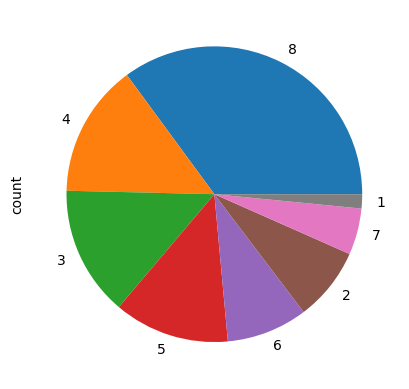

In [142]:
# visualizing the distribution of tcs scores for the data
data3['tcs_day_linear'].value_counts().plot(kind='pie')

In [143]:
data3['tcs_day_linear'].value_counts()

tcs_day_linear
8    2715
4    1126
3    1099
5     978
6     686
2     623
7     393
1     120
Name: count, dtype: int64

In [144]:
# creating copy of dataset to use for linear model
# data3.to_csv("CAPOEDA_LINEAR.csv", index = False)

In [153]:
# loading data
data4 = pd.read_csv("CAPOEDA_LINEAR.csv")
data4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7740 entries, 0 to 7739
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   case_id                  7740 non-null   int64  
 1   dem_age                  7740 non-null   float64
 2   dem_sex                  7740 non-null   float64
 3   dem_pregnant             7740 non-null   float64
 4   dem_trimester            7740 non-null   float64
 5   exam_height              7740 non-null   float64
 6   exam_weight              7740 non-null   float64
 7   exam_hr                  7740 non-null   float64
 8   exam_rr                  7740 non-null   float64
 9   exam_sbp                 7740 non-null   float64
 10  exam_dbp                 7740 non-null   float64
 11  exam_temp                7740 non-null   float64
 12  exam_o2sat               7740 non-null   float64
 13  exam_o2satvalue          7740 non-null   float64
 14  exam_mental             

In [154]:
# drop case_id and lab_wbc columns
data4.drop(['case_id', 'lab_wbc'], axis=1, inplace=True)

In [155]:
data4.head(10)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,day6test___oral,day7test___cough,day7test___afebrile,day7test___wbc,day7test___oral,over7daytest___cough,over7daytest___afebrile,over7daytest___wbc,over7daytest___oral,tcs_day_linear
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,1,0,0,1,1,1,1,8
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,2
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,0,0,0,0,0,0,0,0,6
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,1,1,1,1,1,1,1,1,5
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,5
5,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,1,0,0,0,0,0,0,0,0,5
6,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,4
7,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,0,0,0,0,3
8,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,0,0,0,0,1,1,1,1,8
9,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,0,1,1,0,0,1,1,1,1,8


In [156]:
# dropping all columns which are not demographic, exam, or chest x-ray (cx) variables
data4 = data4.drop(data3.columns[23:-1], axis=1)

In [157]:
data4.head(10)

,dem_age,dem_sex,dem_pregnant,dem_trimester,exam_height,exam_weight,exam_hr,exam_rr,exam_sbp,exam_dbp,...,exam_o2satvalue,exam_mental,cx_rul,cx_rml,cx_rll,cx_lul,cx_lll,cx_cav,cx_pe,tcs_day_linear
0,43.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,8
1,60.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2
2,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,6
3,35.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,5
4,61.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5
5,52.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,5
6,45.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4
7,59.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,3
8,44.0,0.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,8
9,73.0,1.0,0.0,0.0,160.829244,73.044786,99.372304,23.761663,126.184301,72.164604,...,91.711562,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,8


#### Splitting Data

In [ ]:
# selecting explanatory variables (x) - demographic (dem_), exam (exam_) and chest x-ray (cx_) data
X = data4.drop(['tcs_day_linear'], axis=1)

In [159]:
#selecting the tagret variable (y) - tcs score for patients
y = data4['tcs_day_linear']

In [160]:
# Split the data into Train/Test sets using 20% of the data for testing - 4 data frames X_train, X_test, y_train, and y_test
# setting arbitrary random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

#### Training the Linear Regression Model and Executing

In [161]:
regressor=LinearRegression()

#Train your model
regressor.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict y values from the test data set and saving them to variable y_pred
y_pred = regressor.predict(X_test.values)

#### Evaluating Linear Regression Model

In [ ]:
# Train set
y_train_pred = regressor.predict(X_train)
# calculate the mean squared error of the train set
mse_train = mean_squared_error(y_train, y_train_pred)
# calculate the root mean squared error of the train set
rmse_train = np.sqrt(mse_train)

print("MSE (train):", mse_train)
print("RMSE (train):", rmse_train)

# Test set
y_test_pred = regressor.predict(X_test)
# calculate the mean squared error of the train set
mse_test = mean_squared_error(y_test, y_test_pred)
# calculate the root mean squared error of the train set
rmse_test = np.sqrt(mse_test)

print("MSE (test):", mse_test)
print("RMSE (test):", rmse_test)

MSE (train): 4.515734787561701
RMSE (train): 2.1250258322104467
MSE (test): 4.5905950168891145
RMSE (test): 2.1425673891126773


Explain results

In [167]:
# Calculate the R-squared value of the model (Test set only)
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.041308276853380455


Explain results

In [ ]:
# note to self: refer to notebook MLA2_SZM